In [1]:
# ==========================================
# STEP 1 : IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim

# Train-test split
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [3]:
# ==========================================
# STEP 2 : LOAD DATASET
# ==========================================

df = pd.read_csv("/content/Housing.csv")

print("Dataset loaded successfully!")

df.head()

Dataset loaded successfully!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
# ==========================================
# STEP 3 : EXPLORE DATASET
# ==========================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(545, 13)

Column Names:
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea    

In [5]:
# ==========================================
# STEP 4 : CHECK MISSING VALUES
# ==========================================

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [7]:
# ==========================================
# STEP 5 : SELECT REQUIRED COLUMNS
# ==========================================

df = df[["area", "price"]]

print(df.head())

   area     price
0  7420  13300000
1  8960  12250000
2  9960  12250000
3  7500  12215000
4  7420  11410000


In [8]:
# ==========================================
# STEP 6 : HANDLE MISSING VALUES
# ==========================================

print("Missing values before:")
print(df.isnull().sum())

df = df.dropna()

print("\nMissing values after:")
print(df.isnull().sum())

Missing values before:
area     0
price    0
dtype: int64

Missing values after:
area     0
price    0
dtype: int64


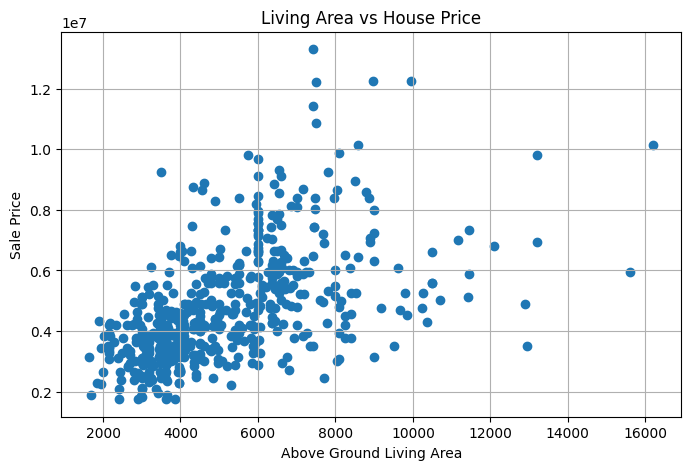

In [10]:
# ==========================================
# STEP 7 : VISUALIZE ORIGINAL DATA
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["area"],
    df["price"]
)

plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")
plt.title("Living Area vs House Price")

plt.grid(True)

plt.show()

In [11]:
# ==========================================
# STEP 8 : SELECT INPUT AND TARGET
# ==========================================

# Input feature
X = df[["area"]]

# Target variable
y = df[["price"]]

print("Input X:")
print(X.head())

print("\nTarget y:")
print(y.head())

Input X:
   area
0  7420
1  8960
2  9960
3  7500
4  7420

Target y:
      price
0  13300000
1  12250000
2  12250000
3  12215000
4  11410000


In [12]:
# ==========================================
# STEP 9 : TRAIN-TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape :", X_test.shape)

Training data shape: (436, 1)
Testing data shape : (109, 1)


In [13]:
# ==========================================
# STEP 10 : CONVERT TO PYTORCH TENSORS
# ==========================================

X_train = torch.tensor(
    X_train.values,
    dtype=torch.float32
)

X_test = torch.tensor(
    X_test.values,
    dtype=torch.float32
)

y_train = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_test = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: torch.Size([436, 1])
X_test shape : torch.Size([109, 1])
y_train shape: torch.Size([436, 1])
y_test shape : torch.Size([109, 1])


In [14]:
# ==========================================
# STEP 11 : BUILD LINEAR REGRESSION MODEL
# ==========================================

class LinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        # 1 input feature and 1 output
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)


model = LinearRegressionModel()

print(model)

LinearRegressionModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [15]:
# ==========================================
# STEP 12 : DEFINE LOSS FUNCTION
# ==========================================

criterion = nn.MSELoss()

print("Loss Function:")
print(criterion)

Loss Function:
MSELoss()


In [16]:
# ==========================================
# STEP 13 : DEFINE ADAM OPTIMIZER
# ==========================================

optimizer = optim.Adam(
    model.parameters(),
    lr=0.000001
)

print("Optimizer:")
print(optimizer)

Optimizer:
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 1e-06
    maximize: False
    weight_decay: 0
)


In [17]:
# ==========================================
# STEP 14 : TRAIN THE MODEL
# ==========================================

epochs = 2000

loss_history = []

for epoch in range(epochs):

    # Forward pass
    predictions = model(X_train)

    # Calculate loss
    loss = criterion(predictions, y_train)

    # Clear previous gradients
    optimizer.zero_grad()

    # Backward pass
    loss.backward()

    # Update weight and bias
    optimizer.step()

    # Store loss
    loss_history.append(loss.item())

    # Display loss
    if (epoch + 1) % 200 == 0:

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Loss: {loss.item():.4f}"
        )

Epoch [200/2000], Loss: 25214140284928.0000
Epoch [400/2000], Loss: 25214131896320.0000
Epoch [600/2000], Loss: 25214117216256.0000
Epoch [800/2000], Loss: 25214104633344.0000
Epoch [1000/2000], Loss: 25214098341888.0000
Epoch [1200/2000], Loss: 25214085758976.0000
Epoch [1400/2000], Loss: 25214073176064.0000
Epoch [1600/2000], Loss: 25214066884608.0000
Epoch [1800/2000], Loss: 25214054301696.0000
Epoch [2000/2000], Loss: 25214043815936.0000


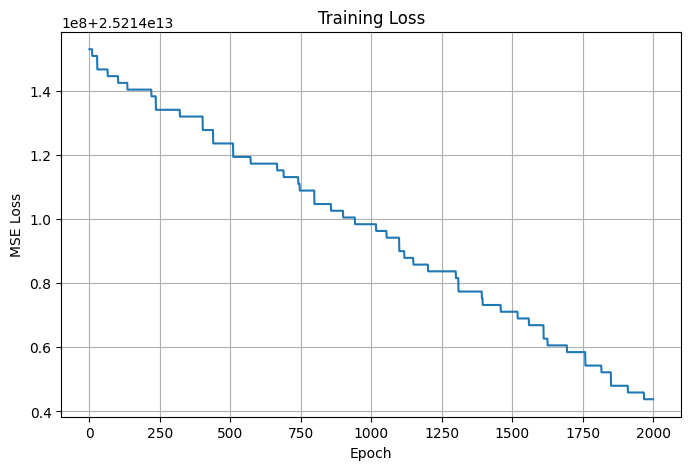

In [18]:
# ==========================================
# STEP 16 : PLOT TRAINING LOSS
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss")

plt.grid(True)

plt.show()

In [19]:
# ==========================================
# STEP 17 : MAKE PREDICTIONS
# ==========================================

model.eval()

with torch.no_grad():

    y_pred = model(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
tensor([[2325.9590],
        [2562.3970],
        [1593.0010],
        [1971.3018],
        [1561.4758],
        [2649.0908],
        [3358.4048],
        [1967.3611],
        [1277.7502],
        [1064.9561]])


In [20]:
# ==========================================
# STEP 18 : COMPARE ACTUAL AND PREDICTED
# ==========================================

print("Actual Price       Predicted Price")

for actual, predicted in zip(y_test[:10], y_pred[:10]):

    print(
        f"{actual.item():.2f}"
        f"          "
        f"{predicted.item():.2f}"
    )

Actual Price       Predicted Price
4060000.00          2325.96
6650000.00          2562.40
3710000.00          1593.00
6440000.00          1971.30
2800000.00          1561.48
4900000.00          2649.09
5250000.00          3358.40
4543000.00          1967.36
2450000.00          1277.75
3353000.00          1064.96


In [21]:
# ==========================================
# STEP 19 : EVALUATE THE MODEL
# ==========================================

# Convert tensors to NumPy arrays
y_test_numpy = y_test.numpy()
y_pred_numpy = y_pred.numpy()

# Mean Squared Error
mse = mean_squared_error(
    y_test_numpy,
    y_pred_numpy
)

# Mean Absolute Error
mae = mean_absolute_error(
    y_test_numpy,
    y_pred_numpy
)

# R2 Score
r2 = r2_score(
    y_test_numpy,
    y_pred_numpy
)

print("MODEL EVALUATION")
print("----------------------------")

print("Mean Squared Error :", mse)
print("Mean Absolute Error:", mae)
print("R2 Score           :", r2)

MODEL EVALUATION
----------------------------
Mean Squared Error : 30107664121856.0
Mean Absolute Error: 5005511.5
R2 Score           : -4.9565229415893555


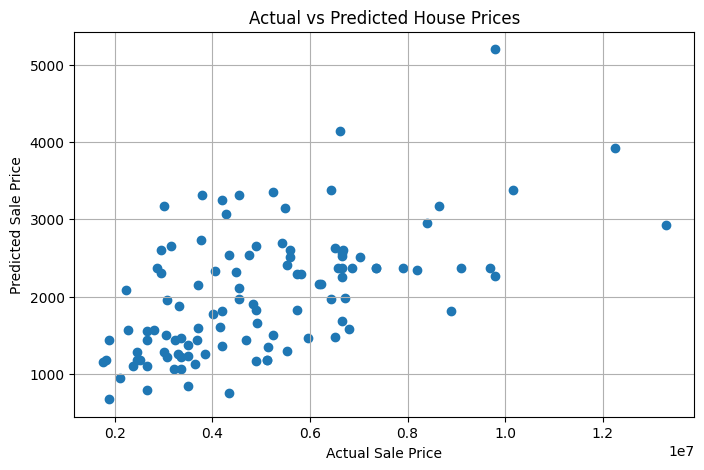

In [22]:
# ==========================================
# STEP 20 : ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_numpy,
    y_pred_numpy
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")

plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

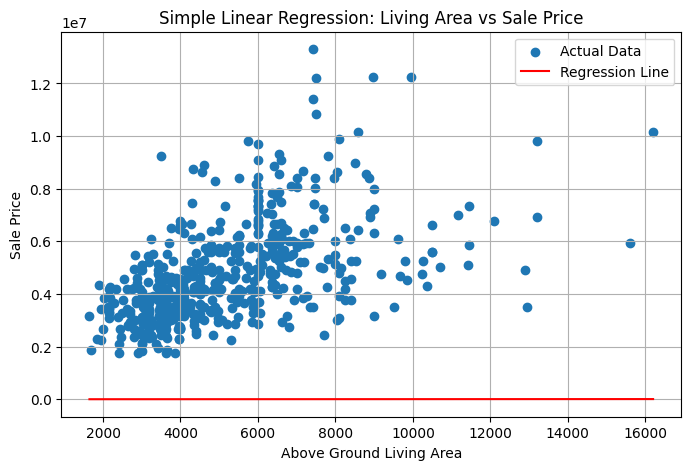

In [25]:
# ==========================================
# STEP 21 : PLOT REGRESSION LINE
# ==========================================

plt.figure(figsize=(8, 5))

# Actual data points
plt.scatter(
    df["area"],
    df["price"],
    label="Actual Data"
)

# Generate x values
x_line = np.linspace(
    df["area"].min(),
    df["area"].max(),
    100
)

# Extract weight and bias from the trained model
weight = model.linear.weight.item()
bias = model.linear.bias.item()

# Calculate predicted y values
y_line = weight * x_line + bias

# Regression line
plt.plot(
    x_line,
    y_line,
    color='red',
    label="Regression Line"
)

plt.xlabel("Above Ground Living Area")
plt.ylabel("Sale Price")

plt.title("Simple Linear Regression: Living Area vs Sale Price")

plt.legend()

plt.grid(True)

plt.show()

In [27]:
# ==========================================
# STEP 22 : PREDICT NEW HOUSE PRICE
# ==========================================

new_area = torch.tensor(
    [[2000.0]],
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    predicted_price = model(new_area)

print(
    "Predicted price for a 2000 sq.ft house:",
    predicted_price.item()
)

Predicted price for a 2000 sq.ft house: 789.1117553710938


In [ ]:
# ==========================================
# STEP 23 : CONCLUSION
# ==========================================

print("""
CONCLUSION
==========

A Simple Linear Regression model was successfully
implemented using PyTorch on the Housing Prices dataset.

GrLivArea, representing the above-ground living area,
was selected as the input feature and SalePrice was
selected as the target variable.

The dataset was loaded, missing values were checked,
and the required columns were selected. The data was
then divided into training and testing sets and
converted into PyTorch tensors.

A PyTorch Linear Regression model was created using
nn.Linear(1,1). Mean Squared Error was used as the loss
function and Adam was used as the optimizer.

The model was trained using forward propagation,
backpropagation and parameter updates.

The model was evaluated using MSE, MAE and R2 Score.
Training loss, actual-vs-predicted values and the
regression line were visualized using Matplotlib.

The observations show that house living area has a
positive relationship with sale price, although a
single-feature linear regression model cannot explain
all the factors that affect house prices.
""")